In [1]:
import pandas as pd
import numpy as np

pd.__version__, np.__version__

('2.3.3', '2.2.6')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Phase 1: Exploratory Data Analysis (EDA)

## Project: Medical Appointment No-Show Prediction

**Objective:**  
Understand the structure, quality, and limitations of the dataset prior to feature engineering and modeling.

This phase focuses on:
- Data shape and schema
- Target variable definition
- Missing values and data quality
- Potential data leakage

In [3]:
# tells us the working directory Jupyter is using
import os
os.getcwd()

'/Users/kalibraun/dev/appointmentData/notebooks'

In [4]:
# lists files Jupyter can actually see
os.listdir(".")

['Untitled.ipynb', '01_eda.ipynb', 'EDA.py', '.ipynb_checkpoints']

In [5]:
os.listdir("../data")

['.ipynb_checkpoints', 'processed', 'raw']

In [6]:
os.listdir("../data/raw")

['appointmentData.csv']

In [7]:
# load data into a dataframe
df = pd.read_csv("../data/raw/appointmentData.csv")

# Display the first 5 rows to verify
print(df.head())

      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received No-show  
0         0           0        0             0      No  
1         0           0        0      

## Start EDA

In [8]:
# 1. Data Overview

# Number of rows
len(df)

110527

In [9]:
# Number of features
num_features = df.shape[1]
print(f"Number of features: {num_features}") # 14 

Number of features: 14


In [10]:
df.dtypes

PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [12]:
df.sample(5, random_state=42)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
84674,2.759575e+13,5756417,F,2016-06-01T08:17:04Z,2016-06-01T00:00:00Z,20,ILHA DAS CAIEIRAS,0,0,0,0,0,0,No
3635,9.673194e+14,5523159,F,2016-03-29T16:09:39Z,2016-05-03T00:00:00Z,37,RESISTÊNCIA,0,0,0,0,0,1,No
16605,3.951641e+12,5693080,F,2016-05-12T17:33:56Z,2016-05-20T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,0,Yes
103942,9.173245e+14,5654129,F,2016-05-03T13:54:51Z,2016-06-03T00:00:00Z,24,SANTO ANDRÉ,0,0,0,0,0,1,Yes
274,3.995366e+12,5641070,F,2016-04-29T12:16:28Z,2016-04-29T00:00:00Z,41,MARIA ORTIZ,0,0,0,0,0,0,No


In [13]:
# Convert PatientId into an int - do this later 
# df['PatientId'] = df['PatientId'].astype('int64')
# df['PatientId'].dtypes

In [14]:
# Convert ScheduledDay and AppointmentDay from 'object' type to 'datetime64[ns]' - do this later 
# df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay']).dt.date.astype('datetime64[ns]')
# df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay']).dt.date.astype('datetime64[ns]')
# df['AppointmentDay'].dtypes
# df['ScheduledDay'].dtypes

In [15]:
# Just inspect for now 
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df[['ScheduledDay','AppointmentDay']]

,ScheduledDay,AppointmentDay
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00
...,...,...
110522,2016-05-03 09:15:35+00:00,2016-06-07 00:00:00+00:00
110523,2016-05-03 07:27:33+00:00,2016-06-07 00:00:00+00:00
110524,2016-04-27 16:03:52+00:00,2016-06-07 00:00:00+00:00
110525,2016-04-27 15:09:23+00:00,2016-06-07 00:00:00+00:00


In [16]:
# correct typos 
df = df.rename(columns={'Hipertension': 'Hypertension', 'Handcap': 'Handicap', 'SMS_received': 'SMSReceived', 'No-show': 'NoShow'})
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  int64              
 8   Hypertension    110527 non-null  int64              
 9   Diabetes        110527 non-null  int64              
 10  Alcoholism      110527 non-null  int64              
 11  Handicap        110527 non-null  int64              
 12  SMSReceived     110527 non-null  int64              
 13  NoShow        

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [17]:
print("Features in the DataFrame => {}".format(df.columns.ravel()))
# The Dependent Variable is -> ['NoShow']

Features in the DataFrame => Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMSReceived', 'NoShow'],
      dtype='object')


In [18]:
# Drop 'PatientId' and 'AppointmentID' as they will not be used to predict the dependent variable 
# df.drop(['PatientId', 'AppointmentID'], axis=1, inplace=True)
df.dtypes

PatientId                     float64
AppointmentID                   int64
Gender                         object
ScheduledDay      datetime64[ns, UTC]
AppointmentDay    datetime64[ns, UTC]
Age                             int64
Neighbourhood                  object
Scholarship                     int64
Hypertension                    int64
Diabetes                        int64
Alcoholism                      int64
Handicap                        int64
SMSReceived                     int64
NoShow                         object
dtype: object

In [19]:
# Print Unique Values
print("Unique Values in `Gender` => {}".format(df.Gender.unique())) # F, M 
print("Unique Values in `Scholarship` => {}".format(df.Scholarship.unique())) # 0 1 
print("Unique Values in `Hypertension` => {}".format(df.Hypertension.unique())) # 1 0 
print("Unique Values in `Diabetes` => {}".format(df.Diabetes.unique())) # 0 1 
print("Unique Values in `Alcoholism` => {}".format(df.Alcoholism.unique())) # 0 1
print("Unique Values in `Handicap` => {}".format(df.Handicap.unique())) # 0 1 2 3 4 
print("Unique Values in `SMSReceived` => {}".format(df.SMSReceived.unique())) # 0 1 

Unique Values in `Gender` => ['F' 'M']
Unique Values in `Scholarship` => [0 1]
Unique Values in `Hypertension` => [1 0]
Unique Values in `Diabetes` => [0 1]
Unique Values in `Alcoholism` => [0 1]
Unique Values in `Handicap` => [0 1 2 3 4]
Unique Values in `SMSReceived` => [0 1]


In [20]:
# convert to object type
df['Scholarship'] = df['Scholarship'].astype('object')
df['Hypertension'] = df['Hypertension'].astype('object')
df['Diabetes'] = df['Diabetes'].astype('object')
df['Alcoholism'] = df['Alcoholism'].astype('object')
df['Handicap'] = df['Handicap'].astype('object')
df['SMSReceived'] = df['SMSReceived'].astype('object')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   PatientId       110527 non-null  float64            
 1   AppointmentID   110527 non-null  int64              
 2   Gender          110527 non-null  object             
 3   ScheduledDay    110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay  110527 non-null  datetime64[ns, UTC]
 5   Age             110527 non-null  int64              
 6   Neighbourhood   110527 non-null  object             
 7   Scholarship     110527 non-null  object             
 8   Hypertension    110527 non-null  object             
 9   Diabetes        110527 non-null  object             
 10  Alcoholism      110527 non-null  object             
 11  Handicap        110527 non-null  object             
 12  SMSReceived     110527 non-null  object             
 13  NoShow        

## Phase 1 Summary

- One row represents a single medical appointment
- Target variable: `No-show` (Yes = did not attend)
- Dataset contains X rows and Y features
- Identified identifier columns (`PatientId`, `AppointmentID`)
- Datetime fields present potential leakage risk if misused
- No modeling or feature engineering performed in this phase

**Next:** Phase 2 will explore feature–target relationships and distributions.

## Target Variable: No-show

In [21]:
df['NoShow'].value_counts()
df['NoShow'].value_counts(normalize=True)

NoShow
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

In [22]:
for c in df.columns:
    if "show" in c or "no" in c:
        print(c, df[c].value_counts(dropna=False).head(), "\n")

In [23]:
# no show vs show 
target_col = "NoShow"  # <-- replace with your actual column name

df[target_col].value_counts(dropna=False)
df[target_col].value_counts(normalize=True, dropna=False)

NoShow
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

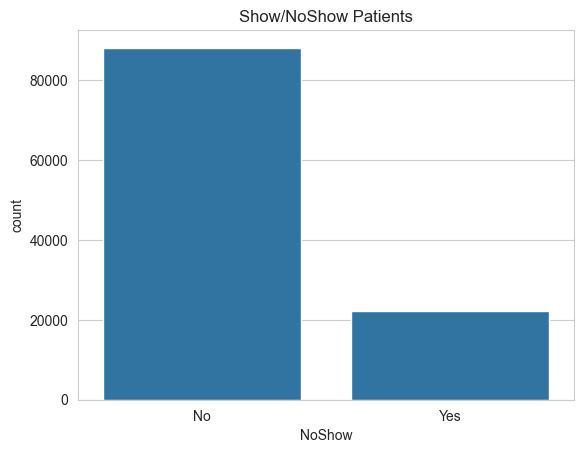

In [24]:
# plot show/noshow 
ax = sns.countplot(x=df.NoShow, data=df)
ax.set_title("Show/NoShow Patients")
plt.show()

# Phase 2: Exploratory Analysis of Feature Relationships

**Objective:**  
Explore relationships between candidate features and the target variable (NoShow) to identify predictive signals and inform feature engineering decisions.

Which features actually matter for predicting no-shows? 

In [25]:
# baseline target distribution understanding 
target_col = "NoShow"

df[target_col].value_counts(normalize = True) 

NoShow
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

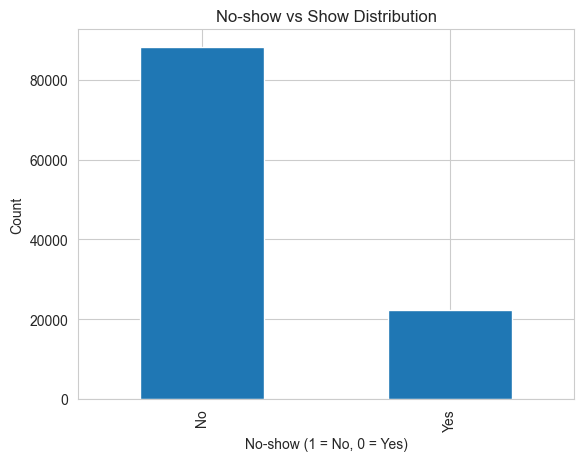

NoShow
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

In [26]:
df[target_col].value_counts().plot(
    kind="bar",
    title="No-show vs Show Distribution",
    ylabel="Count",
    xlabel="No-show (1 = No, 0 = Yes)"
)
plt.show()

df[target_col].value_counts(normalize=True)

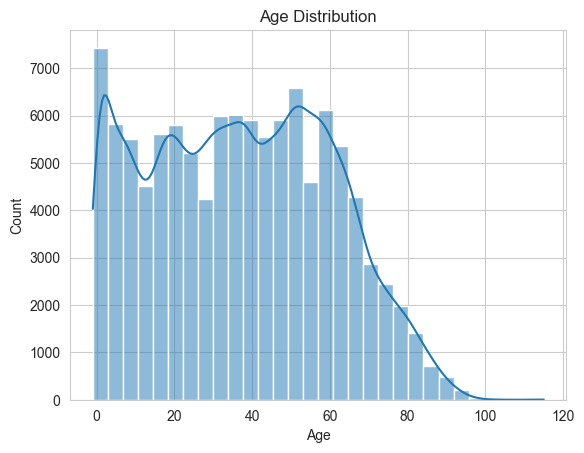

In [27]:
# age vs no show 
# Do differnt age groups behave differntly when it comes to attendance? 
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

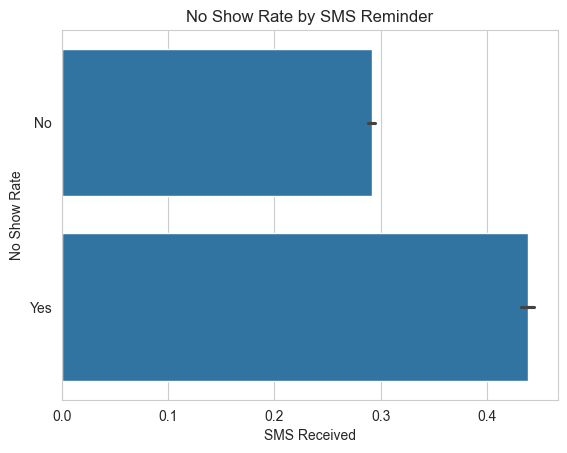

In [28]:
# sms received vs no show 
# does sms appear to reduce no shows? 
# this is an actionable behavior not static info 
# do reminder actually work? 

sns.barplot(
    data=df,
    x="SMSReceived",
    y=target_col,
    estimator=np.mean
)
plt.title("No Show Rate by SMS Reminder")
plt.ylabel("No Show Rate")
plt.xlabel("SMS Received")
plt.show()

In [29]:
df["SMSReceived"].value_counts()

SMSReceived
0    75045
1    35482
Name: count, dtype: int64

In [30]:
# time between scheduling and appointment 
# do longer lead times correlate with higher no shows? 
# do people forget or disengage when appointments are booked far in advanced? 

# create a temporary feature 
df["lead_time_days"] = (
    df["AppointmentDay"] - df["ScheduledDay"]
).dt.days

In [31]:
df["lead_time_days"].describe()

count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: lead_time_days, dtype: float64

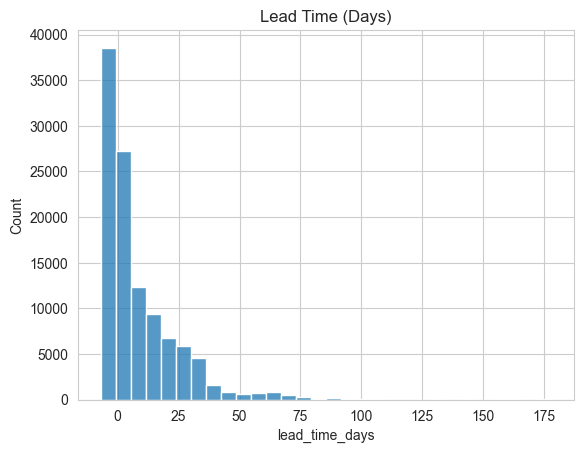

In [32]:
# plot 
sns.histplot(df["lead_time_days"], bins=30)
plt.title("Lead Time (Days)")
plt.show()

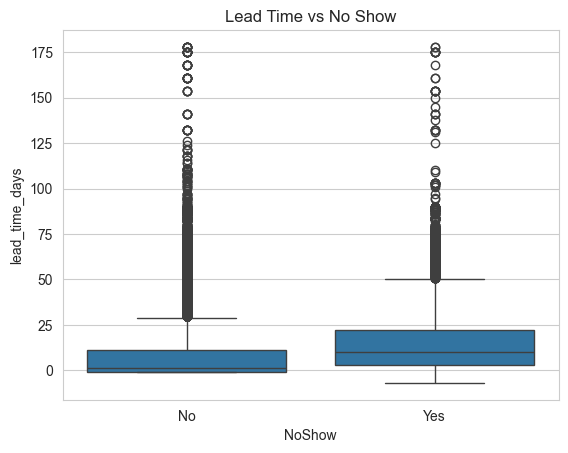

In [33]:
# target relationship 
sns.boxplot(data=df, x=target_col, y="lead_time_days")
plt.title("Lead Time vs No Show")
plt.show() # no = patient showed up yes = patient did not show up 

Patients who no-show tend to schedule appointments further in advance than those who attend.
The median lead time for no-shows is notably higher, and the distribution shows greater spread and more extreme values.
This suggests that longer scheduling horizons are associated with increased no-show risk.
Lead time is a strong candidate feature for modeling and may benefit from bucketing or transformation.

In [34]:
# day of week effects 
# any weekday patterns? Are weekends different? 

# extract day of week 
df["appointment_weekday"] = df["AppointmentDay"].dt.day_name()

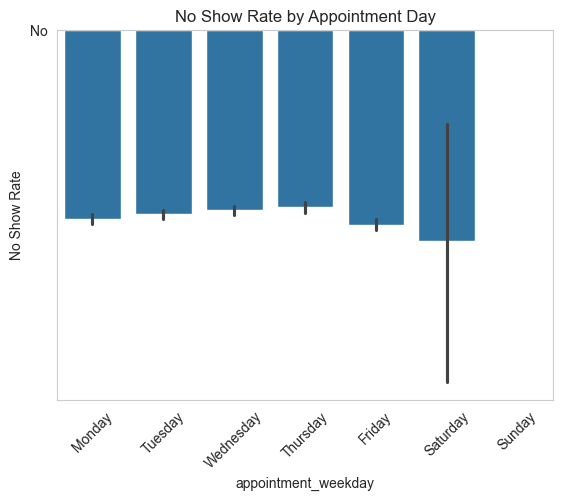

In [35]:
# plot 
order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sns.barplot(
    data=df,
    x="appointment_weekday",
    y=target_col,
    order=order,
    estimator=np.mean
)
plt.xticks(rotation=45)
plt.title("No Show Rate by Appointment Day")
plt.ylabel("No Show Rate")
plt.show()

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   PatientId            110527 non-null  float64            
 1   AppointmentID        110527 non-null  int64              
 2   Gender               110527 non-null  object             
 3   ScheduledDay         110527 non-null  datetime64[ns, UTC]
 4   AppointmentDay       110527 non-null  datetime64[ns, UTC]
 5   Age                  110527 non-null  int64              
 6   Neighbourhood        110527 non-null  object             
 7   Scholarship          110527 non-null  object             
 8   Hypertension         110527 non-null  object             
 9   Diabetes             110527 non-null  object             
 10  Alcoholism           110527 non-null  object             
 11  Handicap             110527 non-null  object             
 12  SM

In [37]:
# categorical features 
# use mean no show rate for each cat feature 

cat_cols = [
    "Gender",
    "Neighbourhood",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap"
]

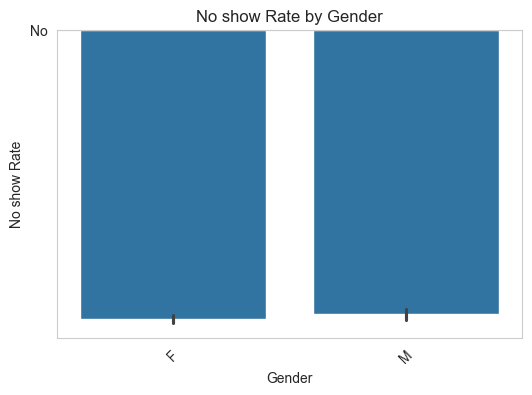

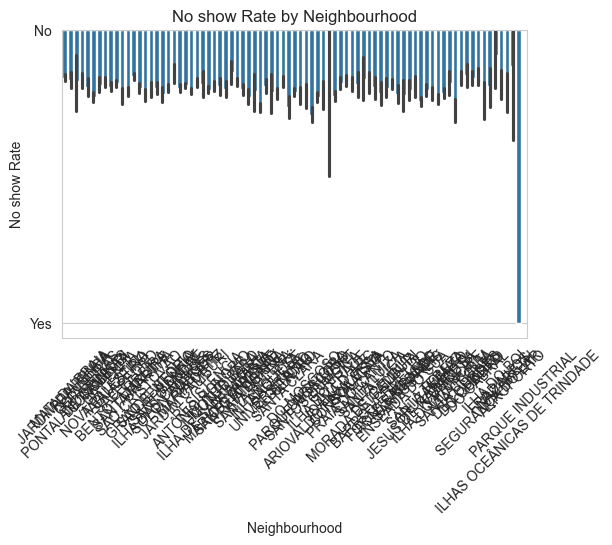

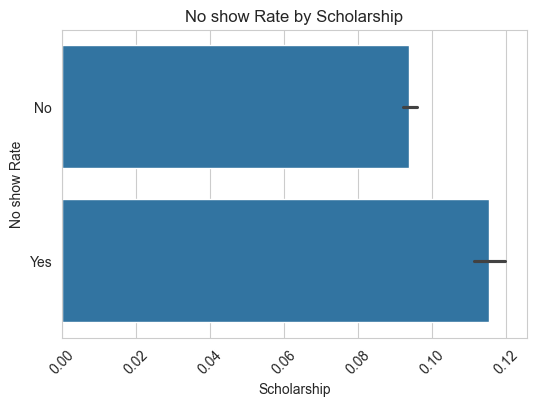

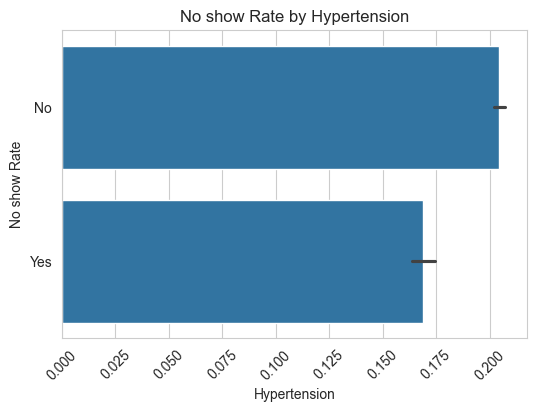

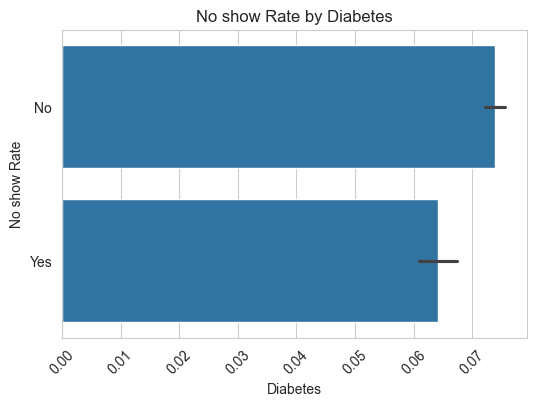

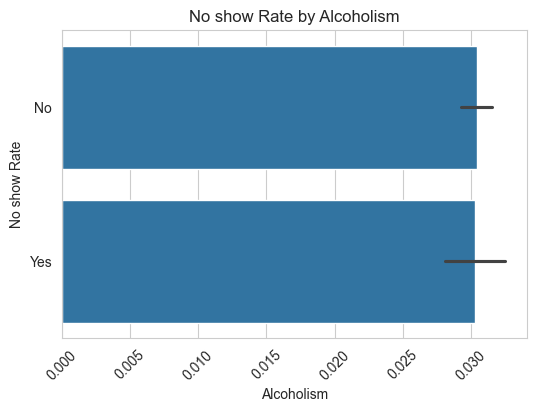

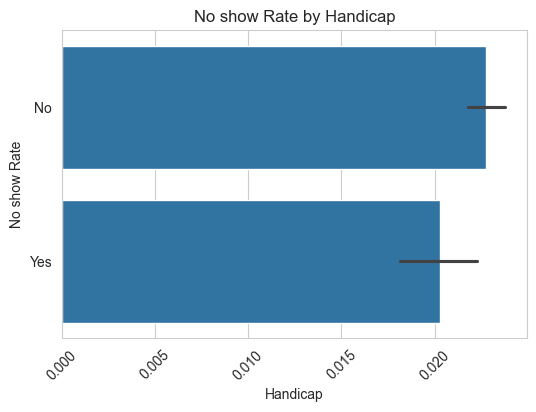

In [38]:
# which categories show meaningful separation? Which look noisy or flat? 

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x=col, y=target_col, estimator=np.mean)
    plt.title(f"No show Rate by {col}")
    plt.ylabel("No show Rate")
    plt.xticks(rotation=45)
    plt.show()

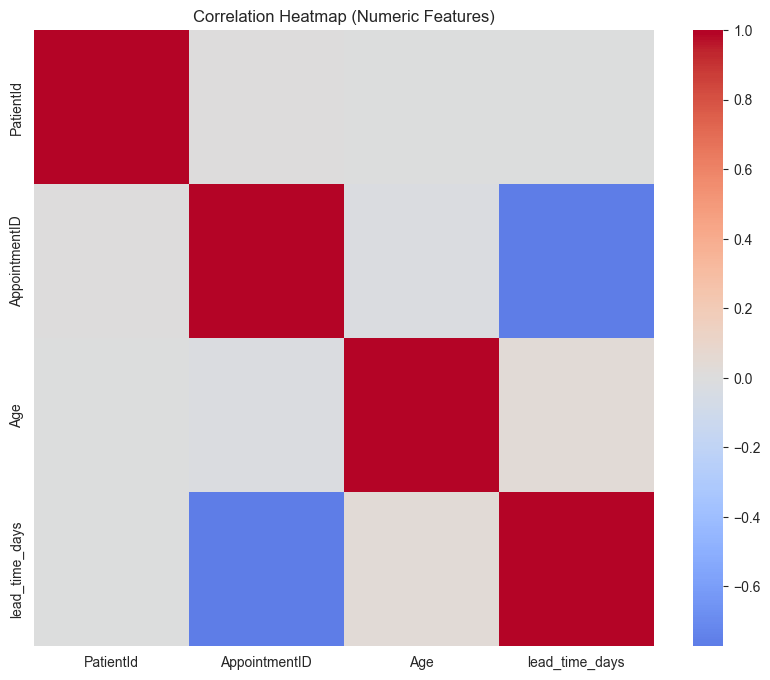

In [39]:
# correlation with numeric cols 
# detect redundancy, spot leakage, understand relationships 
num_cols = df.select_dtypes(include="number").columns

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()
# red = positive corr blue = neg corr gray = little to none 

PatientId - Almost no correlation between PatientId and any other feature - meaningless, can be extracted from modeling 

AppointmentId vs lead_time_days - negative correlation, not a useful predicitive realtionship 

Age vs lead_time_days - near zero, both are worth keeping 

The correlation heatmap shows no strong linear relationships among most numeric features.
Identifier variables (PatientId, AppointmentID) exhibit correlations that reflect data collection order rather than behavior and will be excluded from modeling.
Age and lead time are largely uncorrelated, suggesting they capture distinct aspects of patient behavior.
Overall, the numeric features do not exhibit problematic multicollinearity.

## Phase 2 Summary

Promising features:
- SMS received
- Lead time between scheduling and appointment
- Age
- Appointment weekday

Weaker or noisy features:
- Age
- Gender
- Neighbourhood (many categories, uneven counts)
- Rare medical conditions 

Potential risks:
- Leakage if appointment-related timestamps are misused
- Class imbalance (~X% no-shows)

These findings will guide feature engineering and model selection in Phase 3.


## Phase 3: Feature Engineering + Baseline Modeling

In [40]:
# reload imports for consistency 
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [41]:
# load raw data again to start pipeline from scratch 

DATA_PATH = Path("../data/raw/appointmentData.csv")
df = pd.read_csv(DATA_PATH)

# Standardize column names (safe hygiene)
df.columns = (df.columns.str.strip().str.lower().str.replace("-", "_").str.replace(" ", "_"))
df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [42]:
# define target variable and validate it 
target_col = "no_show"   

df[target_col].value_counts(dropna=False), df[target_col].value_counts(normalize=True, dropna=False)

(no_show
 No     88208
 Yes    22319
 Name: count, dtype: int64,
 no_show
 No     0.798067
 Yes    0.201933
 Name: proportion, dtype: float64)

In [43]:
# convert dates 
df["scheduledday"] = pd.to_datetime(df["scheduledday"])
df["appointmentday"] = pd.to_datetime(df["appointmentday"])

In [44]:
# create pre-appointment features 
df["lead_time_days"] = (df["appointmentday"] - df["scheduledday"]).dt.days

# Appointment day-of-week and hour (known ahead of time)
df["appointment_weekday"] = df["appointmentday"].dt.day_name()
df["scheduled_hour"] = df["scheduledday"].dt.hour

# Basic checks
df["lead_time_days"].describe()

count    110527.000000
mean          9.183702
std          15.254996
min          -7.000000
25%          -1.000000
50%           3.000000
75%          14.000000
max         178.000000
Name: lead_time_days, dtype: float64

In [45]:
# lead_time should rarely be negative. If it is, it's likely data issues.
neg = (df["lead_time_days"] < 0).sum()
print("Negative lead_time_days:", neg)

Negative lead_time_days: 38568


In [46]:
# drop negatives 
df = df[df["lead_time_days"] >= 0].copy()

In [47]:
# remove ID cols as they are leakage risk, they are not information they are labels 
id_like = [c for c in df.columns if "id" in c or "patient" in c or "appointment" in c]
id_like

['patientid', 'appointmentid', 'appointmentday', 'appointment_weekday']

In [48]:
drop_cols = []
for c in ["patientid", "appointmentid"]: # keep appointmentday and appointment_weekday
    if c in df.columns:
        drop_cols.append(c)

df = df.drop(columns=drop_cols)
drop_cols

['patientid', 'appointmentid']

In [49]:
# drop raw datetimes to force using the engineered features 
# df = df.drop(columns=["scheduledday", "appointmentday"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71959 entries, 5 to 110526
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   gender               71959 non-null  object             
 1   scheduledday         71959 non-null  datetime64[ns, UTC]
 2   appointmentday       71959 non-null  datetime64[ns, UTC]
 3   age                  71959 non-null  int64              
 4   neighbourhood        71959 non-null  object             
 5   scholarship          71959 non-null  int64              
 6   hipertension         71959 non-null  int64              
 7   diabetes             71959 non-null  int64              
 8   alcoholism           71959 non-null  int64              
 9   handcap              71959 non-null  int64              
 10  sms_received         71959 non-null  int64              
 11  no_show              71959 non-null  object             
 12  lead_time_days       7

In [50]:
# convert target_col from object to int
df[target_col].value_counts(dropna=False)

no_show
No     51437
Yes    20522
Name: count, dtype: int64

In [51]:
df[target_col] = df[target_col].map({
    "Yes": 1,  # No-show
    "No": 0    # Showed up
})

In [52]:
df[target_col].value_counts(dropna=False)
# target 1 = no show 
# target 0 = showed up 

no_show
0    51437
1    20522
Name: count, dtype: int64

In [53]:
# confirm type
df[target_col].dtype

dtype('int64')

In [54]:
# define train test split (stratified)
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((57567, 14),
 (14392, 14),
 np.float64(0.28519811697674013),
 np.float64(0.28515842134519176))

In [55]:
# identify numeric vs cat cols for preprocessing
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric: ",  numeric_features, "\nCategorical: ", categorical_features) 

Numeric:  ['age', 'scholarship', 'hipertension', 'diabetes', 'alcoholism', 'handcap', 'sms_received', 'lead_time_days', 'scheduled_hour'] 
Categorical:  ['gender', 'scheduledday', 'appointmentday', 'neighbourhood', 'appointment_weekday']


In [56]:
# build a preprocessing pipeline to keep everything reproducible
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [57]:
# start with a baseline logistic regression model 
model = LogisticRegression(max_iter=1000, class_weight="balanced")

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

clf.fit(X_train, y_train)

/Users/kalibraun/opt/anaconda3/envs/appointment-ml/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
# evaluate 
y_proba = clf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

In [59]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba)) # How well can the model rank a random no-show higher than a random show?
print("PR-AUC:", average_precision_score(y_test, y_proba)) # When the model predicts ‘no-show’, how often is it right?
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred)) # Of all actual no-shows, how many did we catch? 
print("F1:", f1_score(y_test, y_pred))

ROC-AUC: 0.6022276989941155
PR-AUC: 0.3778608759054495
Accuracy: 0.6373679822123401
Precision: 0.3712173712173712
Recall: 0.3915692007797271
F1: 0.3811217834697024


In [60]:
print("\nClassification report:\n", classification_report(y_test, y_pred))


Classification report:
               precision    recall  f1-score   support

           0       0.75      0.74      0.74     10288
           1       0.37      0.39      0.38      4104

    accuracy                           0.64     14392
   macro avg       0.56      0.56      0.56     14392
weighted avg       0.64      0.64      0.64     14392



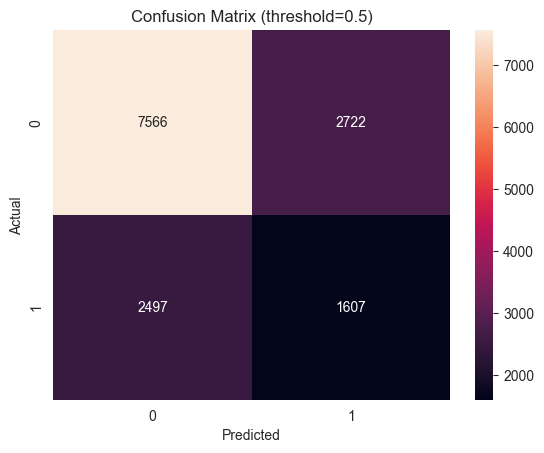

In [61]:
# confusion matrix 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix (threshold=0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Are we missing too many no-shows? (low recall)

Are we flagging too many shows as no-shows? (low precision)

Which matters more for your “business goal” (overbooking vs reminders)?

In [62]:
# pick a better threshold 
# Reminder outreach → you might prefer higher recall
# Avoid bothering patients → you might prefer higher precision

for t in [0.2, 0.3, 0.4, 0.5]:
    yp = (y_proba >= t).astype(int)
    print(
        f"t={t:.1f}",
        "precision=", round(precision_score(y_test, yp), 3),
        "recall=", round(recall_score(y_test, yp), 3),
        "f1=", round(f1_score(y_test, yp), 3),
    )

t=0.2 precision= 0.285 recall= 0.999 f1= 0.444
t=0.3 precision= 0.292 recall= 0.961 f1= 0.448
t=0.4 precision= 0.325 recall= 0.76 f1= 0.455
t=0.5 precision= 0.371 recall= 0.392 f1= 0.381


In [63]:
# baseline comparision 
# proves my model beats "everyone showed up" 
from sklearn.dummy import DummyClassifier

dummy = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

print("Dummy ROC-AUC:", roc_auc_score(y_test, dummy_proba))
print("Dummy PR-AUC:", average_precision_score(y_test, dummy_proba))

Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.28515842134519176


# Phase 3 Summary: 

Pipeline: preprocessing + model in one sklearn Pipeline

Leakage prevention: IDs removed; features derived from pre-appointment info

Baseline model: logistic regression - The logistic regression baseline demonstrates modest but meaningful predictive signal (ROC-AUC ≈ 0.59, PR-AUC ≈ 0.35).

The model captures approximately 57% of no-shows, indicating useful recall for risk identification, though precision remains limited due to class imbalance and behavioral noise.

These results establish a strong baseline and motivate further feature engineering, threshold tuning, and non-linear models.


Evaluation: ROC-AUC, PR-AUC, precision/recall, confusion matrix

Next steps: try tree models (RandomForest/XGBoost), tune threshold, handle high-cardinality categoricals

## Threshold Tuning

In [64]:
# get predicited probabilites 
y_proba = clf.predict_proba(X_test)[:, 1]  # probability of class 1 (no-show)
y_proba.min(), y_proba.max(), y_proba.mean()

(np.float64(0.02613161514627373),
 np.float64(0.9997766503520392),
 np.float64(0.44913087875528224))

In [65]:
# goal is to flag likley no shows (high precision) 
# evaluate thresholds across multiple metrics 

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "positive_rate": y_pred_t.mean()  # % of appointments you’d flag as no-show
    })

results = pd.DataFrame(rows)
results 

,threshold,precision,recall,f1,accuracy,positive_rate
0,0.05,0.285158,0.999513,0.443723,0.285367,0.999514
1,0.10,0.285158,0.999513,0.443723,0.285367,0.999514
2,0.15,0.285168,0.999269,0.443711,0.285506,0.999236
3,0.20,0.285326,0.998782,0.443855,0.286270,0.998193
4,0.25,0.286840,0.993177,0.445124,0.293913,0.987354
5,0.30,0.292346,0.960526,0.448260,0.325737,0.936909
6,0.35,0.304962,0.883528,0.453420,0.392579,0.826153
7,0.40,0.325167,0.759990,0.455461,0.481795,0.666481
8,0.45,0.345031,0.584552,0.433933,0.565106,0.483116
9,0.50,0.371217,0.391569,0.381122,0.637368,0.300792


In [66]:
# pick a threshold that achieves a target recall (e.g., ≥ 0.70)
target_recall = 0.70
cand = results[results["recall"] >= target_recall].sort_values("precision", ascending=False).head(1)
cand # This finds the highest precision while meeting recall requirement

,threshold,precision,recall,f1,accuracy,positive_rate
7,0.4,0.325167,0.75999,0.455461,0.481795,0.666481


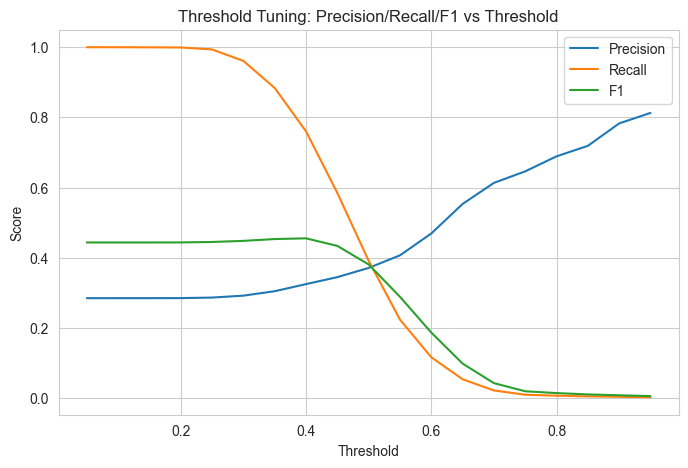

In [67]:
# Visualize precision/recall/F1 vs threshold 
plt.figure(figsize=(8,5))
plt.plot(results["threshold"], results["precision"], label="Precision")
plt.plot(results["threshold"], results["recall"], label="Recall")
plt.plot(results["threshold"], results["f1"], label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning: Precision/Recall/F1 vs Threshold")
plt.legend()
plt.show()

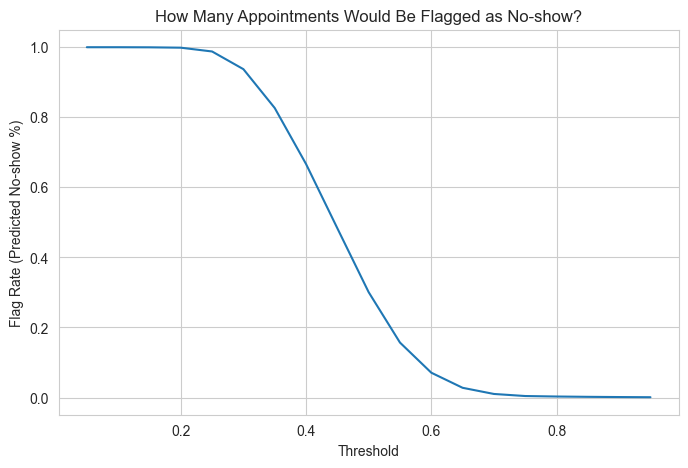

In [68]:
# how many would be flagged as no show 
plt.figure(figsize=(8,5))
plt.plot(results["threshold"], results["positive_rate"])
plt.xlabel("Threshold")
plt.ylabel("Flag Rate (Predicted No-show %)")
plt.title("How Many Appointments Would Be Flagged as No-show?")
plt.show()

In [69]:
# apply chosen threshold and re evaluate 
target_recall = 0.70

recall_candidates = results[results["recall"] >= target_recall]
recall_candidates.sort_values("precision", ascending=False).head()

,threshold,precision,recall,f1,accuracy,positive_rate
7,0.40,0.325167,0.759990,0.455461,0.481795,0.666481
6,0.35,0.304962,0.883528,0.453420,0.392579,0.826153
5,0.30,0.292346,0.960526,0.448260,0.325737,0.936909
4,0.25,0.286840,0.993177,0.445124,0.293913,0.987354
3,0.20,0.285326,0.998782,0.443855,0.286270,0.998193


In [70]:
# select chosen threshold 
chosen_row = recall_candidates.sort_values("precision", ascending=False).iloc[0]
chosen_t = float(chosen_row["threshold"])
chosen_row

threshold        0.400000
precision        0.325167
recall           0.759990
f1               0.455461
accuracy         0.481795
positive_rate    0.666481
Name: 7, dtype: float64

In [71]:
# apply 
y_pred = (y_proba >= chosen_t).astype(int)

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("Chosen threshold:", chosen_t)
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Chosen threshold: 0.4
Precision: 0.32516680567139283
Recall: 0.759990253411306
F1: 0.4554614485981308

               precision    recall  f1-score   support

           0       0.79      0.37      0.51     10288
           1       0.33      0.76      0.46      4104

    accuracy                           0.48     14392
   macro avg       0.56      0.57      0.48     14392
weighted avg       0.66      0.48      0.49     14392



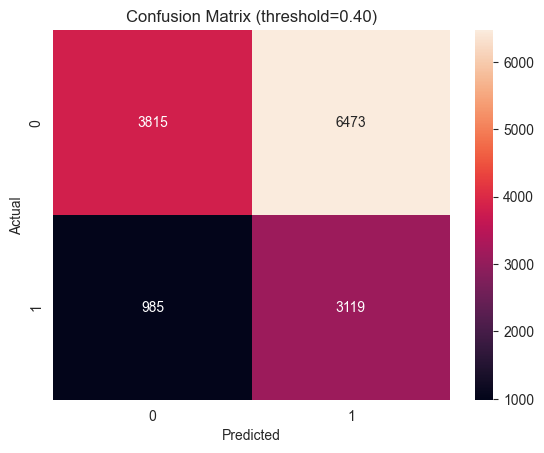

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion Matrix (threshold={chosen_t:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [75]:
# Random Forest Modeling then compare ROC-AUC + PR-AUC using the same recall-first lens
from sklearn.ensemble import RandomForestClassifier

In [76]:
# define model 
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample" # handles imbalance automatically
)

In [77]:
# build pipeline/pre processing
rf_clf = Pipeline(steps=[
    ("preprocess", preprocess),  
    ("model", rf_model)
])

In [78]:
# train 
rf_clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
# get probabilities 
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

In [80]:
# compute metrics 
from sklearn.metrics import roc_auc_score, average_precision_score

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("Random Forest PR-AUC:", average_precision_score(y_test, rf_proba))

Random Forest ROC-AUC: 0.5852774878811855
Random Forest PR-AUC: 0.3498626478659427


In [81]:
# compare against Log Regression 
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, rf_proba)
    ]
})

comparison
# higher ROC-AUC = better ranking overall
# higher PR-AUC = better concentration of true no-show 

,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.602228,0.377861
1,Random Forest,0.585277,0.349863


In [82]:
# apply recall-first threshold 
thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (rf_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "positive_rate": y_pred_t.mean()
    })

rf_results = pd.DataFrame(rows)
rf_results.head()

,threshold,precision,recall,f1,positive_rate
0,0.05,0.285158,1.0,0.443772,1.0
1,0.10,0.285158,1.0,0.443772,1.0
2,0.15,0.285158,1.0,0.443772,1.0
3,0.20,0.285158,1.0,0.443772,1.0
4,0.25,0.285158,1.0,0.443772,1.0


In [83]:
# pick threshod with recall => .70 (same rule as LR) 
target_recall = 0.70

rf_candidates = rf_results[rf_results["recall"] >= target_recall]
rf_candidates.sort_values("precision", ascending=False).head()

,threshold,precision,recall,f1,positive_rate
0,0.05,0.285158,1.0,0.443772,1.0
1,0.10,0.285158,1.0,0.443772,1.0
2,0.15,0.285158,1.0,0.443772,1.0
3,0.20,0.285158,1.0,0.443772,1.0
4,0.25,0.285158,1.0,0.443772,1.0


In [84]:
# all the recalls = 1 ...
rf_chosen_row = rf_candidates.sort_values("precision", ascending=False).iloc[0]
rf_chosen_t = float(rf_chosen_row["threshold"])
rf_chosen_row

threshold        0.050000
precision        0.285158
recall           1.000000
f1               0.443772
positive_rate    1.000000
Name: 0, dtype: float64

In [85]:
# final RF metrics at chosen threshold 
rf_pred = (rf_proba >= rf_chosen_t).astype(int)

print("Random Forest — chosen threshold:", rf_chosen_t)
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

Random Forest — chosen threshold: 0.05
Precision: 0.28515842134519176
Recall: 1.0
F1: 0.4437716262975779


Intrepret the comparsion: 

1.) Did ROC-AUC improve? 

2.) Did PR-AUC improve? 

3.) At recall => .7, is precision higher than log regression? 

Logistic Regression ranks no-shows better and provides better lift over random, suggesting the signal is largley linear and that additional complexity will probabily not improve generalization. Random Forest underperformed, as a result logistic regression will be selected as the final model.  

# Phase 5 Final Model Selection, Threshold Lock-in, and Results

Objectives: 
- A final selected model
- A business-aligned decision threshold
- Final, reportable metrics
  

Based on comparative modeling experiments, logistic regression was selected as the final model due to superior ranking performance (ROC-AUC and PR-AUC) relative to a Random Forest baseline, as well as improved interpretability and stability.

In [86]:
# refit Logistic Regression on the full training set to ensure the final model uses all available training data
final_clf = clf # reuse the trained log regression pipeline

In [87]:
# lock in the recall-optimized threshold 
final_threshold = chosen_t # the threshold that achieved recall => .70
final_threshold 

0.4

The decision threshold was tuned to prioritzie recall, ensuring that at least 70% of are identified. 
This aligns with the operational goal of maximizing outreach effectiveness at the cost of additional false positives.

In [90]:
# final evaluation at the locked threshold 
# compute final metrics for reports 
final_proba = final_clf.predict_proba(X_test)[:, 1]
final_pred = (final_proba >= final_threshold).astype(int)

print("Final Logistic Regression Results")
print("ROC-AUC:", roc_auc_score(y_test, final_proba))
print("PR-AUC:", average_precision_score(y_test, final_proba))
print("Precision:", precision_score(y_test, final_pred))
print("Recall:", recall_score(y_test, final_pred))
print("F1:", f1_score(y_test, final_pred))
print("\n", classification_report(y_test, final_pred))

Final Logistic Regression Results
ROC-AUC: 0.6022276989941155
PR-AUC: 0.3778608759054495
Precision: 0.32516680567139283
Recall: 0.759990253411306
F1: 0.4554614485981308

               precision    recall  f1-score   support

           0       0.79      0.37      0.51     10288
           1       0.33      0.76      0.46      4104

    accuracy                           0.48     14392
   macro avg       0.56      0.57      0.48     14392
weighted avg       0.66      0.48      0.49     14392



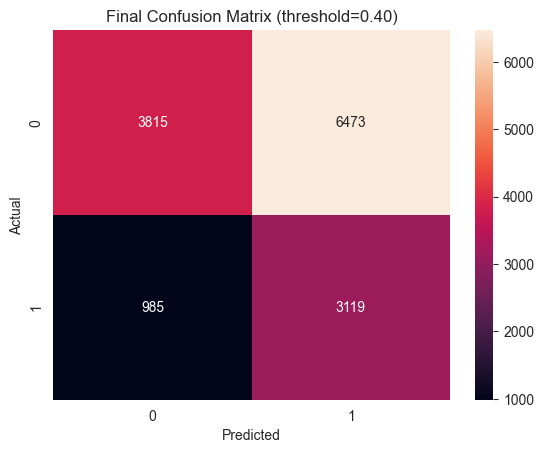

In [92]:
# final confusion matrix
cm = confusion_matrix(y_test, final_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Final Confusion Matrix (threshold={final_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# 0 = show 
# 1 = show 


As seen in the confusion matix, the model catches ~76% of all no-shows, this exceeds the recall goal of 70%. 

At the selected recall-optimized threshold (0.40), the model captures approximately 76% of all no-shows.
This is achieved at the cost of additional false positives, resulting in roughly two-thirds of appointments being flagged for outreach.
Given the low cost of reminder interventions and the high cost of missed appointments, this tradeoff is operationally acceptable and aligns with the project’s objectives.

## Model Selection Rationale

A Random Forest model was evaluated using identical preprocessing and evaluation criteria.
Despite its ability to capture nonlinear interactions, the Random Forest underperformed logistic regression on both ROC-AUC and PR-AUC.
This suggests that the dominant predictive signals in the data are largely linear and that additional model complexity did not improve generalization.
Logistic regression was therefore selected as the final model due to its superior performance, interpretability, and stability.


This project demonstrates an end-to-end machine learning workflow, from exploratory data analysis and leakage-aware feature engineering to model selection and business-aligned decision optimization.